In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip '/content/drive/MyDrive/Group j.zip'

Archive:  /content/drive/MyDrive/Group j.zip
   creating: Group j/
   creating: Group j/Kaf_End/
  inflating: Group j/Kaf_End/AHCR_00001_Kaf_End_22.jpg  
  inflating: Group j/Kaf_End/AHCR_00001_Kaf_End_23.jpg  
  inflating: Group j/Kaf_End/AHCR_00001_Kaf_End_30.jpg  
  inflating: Group j/Kaf_End/AHCR_00001_Kaf_End_31.jpg  
  inflating: Group j/Kaf_End/AHCR_00002_Kaf_End_22.jpg  
  inflating: Group j/Kaf_End/AHCR_00002_Kaf_End_23.jpg  
  inflating: Group j/Kaf_End/AHCR_00002_Kaf_End_30.jpg  
  inflating: Group j/Kaf_End/AHCR_00002_Kaf_End_31.jpg  
  inflating: Group j/Kaf_End/AHCR_00004_Kaf_End_22.jpg  
  inflating: Group j/Kaf_End/AHCR_00004_Kaf_End_23.jpg  
  inflating: Group j/Kaf_End/AHCR_00004_Kaf_End_30.jpg  
  inflating: Group j/Kaf_End/AHCR_00004_Kaf_End_31.jpg  
  inflating: Group j/Kaf_End/AHCR_00005_Kaf_End_22.jpg  
  inflating: Group j/Kaf_End/AHCR_00005_Kaf_End_23.jpg  
  inflating: Group j/Kaf_End/AHCR_00005_Kaf_End_30.jpg  
  inflating: Group j/Kaf_End/AHCR_00005_Kaf_End_

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


img_width, img_height = 150, 150
data_dir = "/content/Group j"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path):  
                img_path = os.path.join(group_path, img_file)
                try:
                   
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2985, Testing samples: 747
Number of classes: 8


In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [10]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


187/187 ━━━━━━━━━━━━━━━━━━━━ 33s 124ms/step - accuracy: 0.1652 - loss: 2.1559 - val_accuracy: 0.5930 - val_loss: 1.1508
Epoch 2/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5267 - loss: 1.2748 - val_accuracy: 0.7952 - val_loss: 0.6597
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6656 - loss: 0.9107 - val_accuracy: 0.8648 - val_loss: 0.4105
Epoch 4/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7531 - loss: 0.7218 - val_accuracy: 0.8942 - val_loss: 0.3540
Epoch 5/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.7832 - loss: 0.6609 - val_accuracy: 0.9076 - val_loss: 0.2854
Epoch 6/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.8016 - loss: 0.5657 - val_accuracy: 0.9036 - val_loss: 0.2905
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8106 - loss: 0.5556 - val_accuracy: 0.9197 - val_loss: 0.2345
Epoch 8/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8459 - loss: 0.4942 - val_accuracy: 0

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9441 - loss: 0.1637
Train Accuracy: 88.58%
Test Accuracy: 94.24%


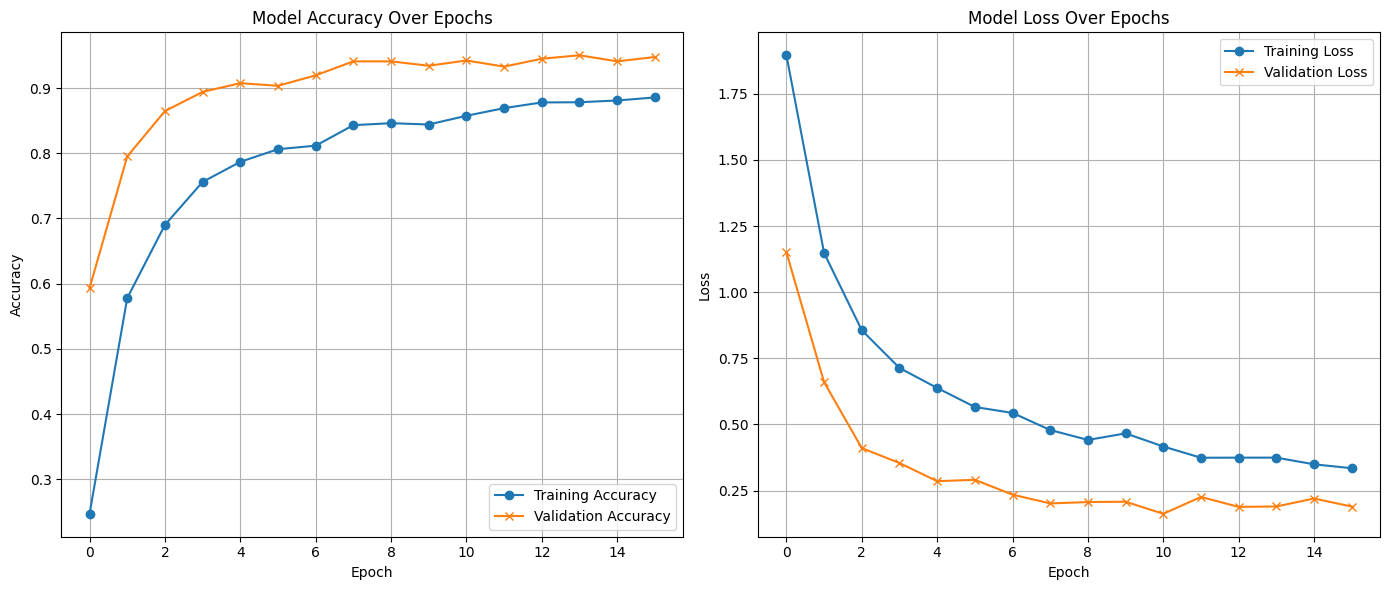

In [12]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


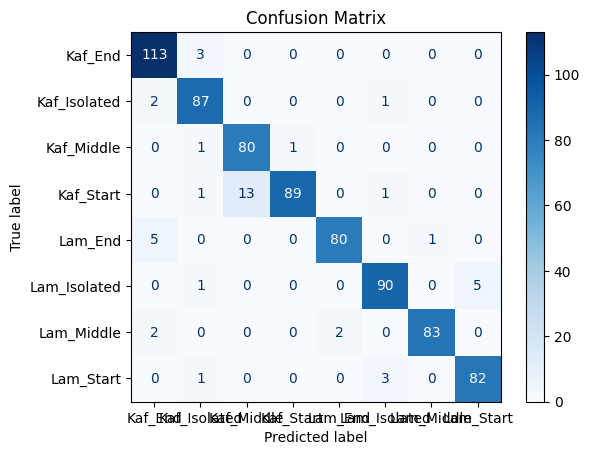

Number of incorrect predictions: 43


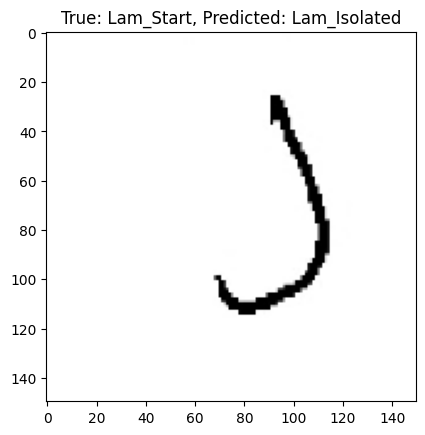

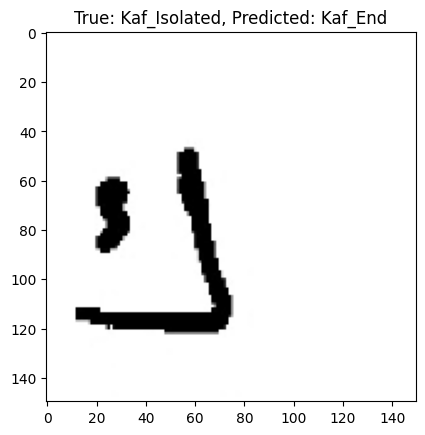

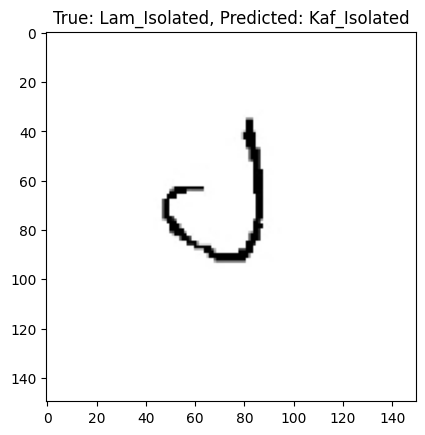

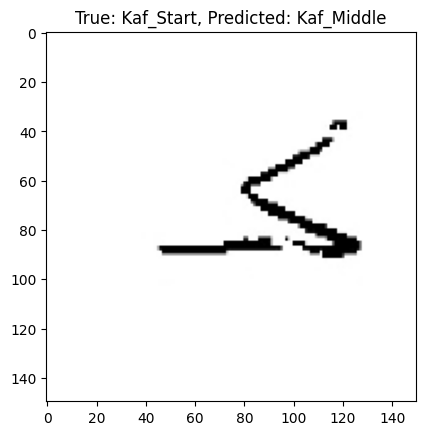

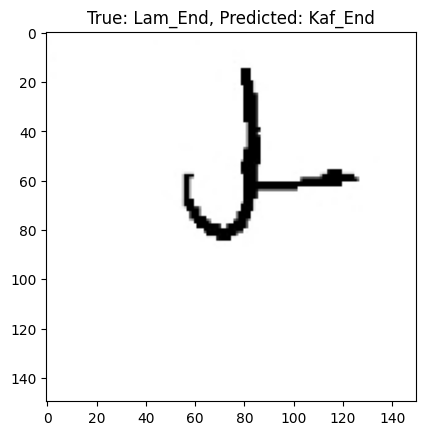

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease dropout and epochs 

In [15]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [16]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.2227 - loss: 1.9979 - val_accuracy: 0.7068 - val_loss: 0.8438
Epoch 2/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.6867 - loss: 0.9169 - val_accuracy: 0.8286 - val_loss: 0.4896
Epoch 3/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7783 - loss: 0.6502 - val_accuracy: 0.8876 - val_loss: 0.3337
Epoch 4/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8414 - loss: 0.4989 - val_accuracy: 0.8782 - val_loss: 0.3327
Epoch 5/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8433 - loss: 0.4547 - val_accuracy: 0.9157 - val_loss: 0.2556
Epoch 6/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8793 - loss: 0.3587 - val_accuracy: 0.9050 - val_loss: 0.2679
Epoch 7/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.8908 - loss: 0.3484 - val_accuracy: 0.9317 - val_loss: 0.1872
Epoch 8/28
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8835 - loss: 0.3409 - val_accuracy: 

In [18]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9743 - loss: 0.1063
Train Accuracy: 95.18%
Test Accuracy: 97.05%


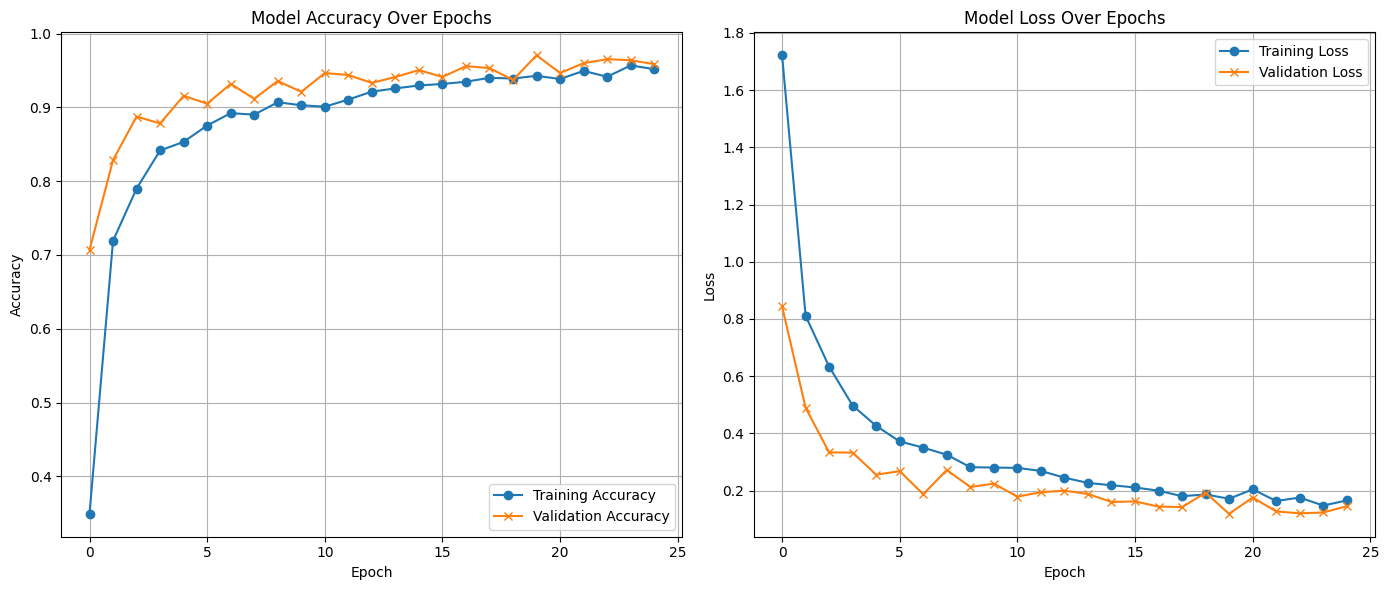

In [19]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


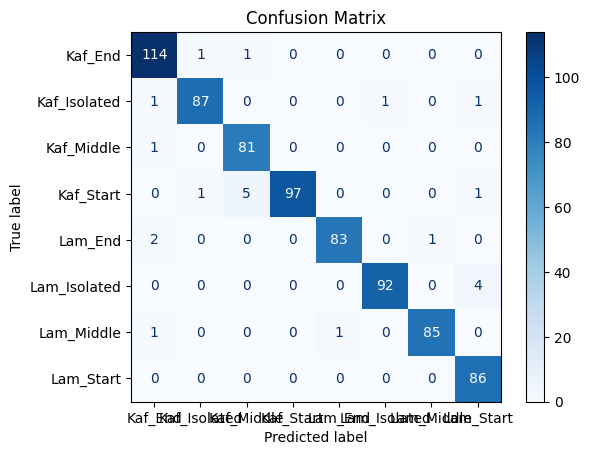

Number of incorrect predictions: 22


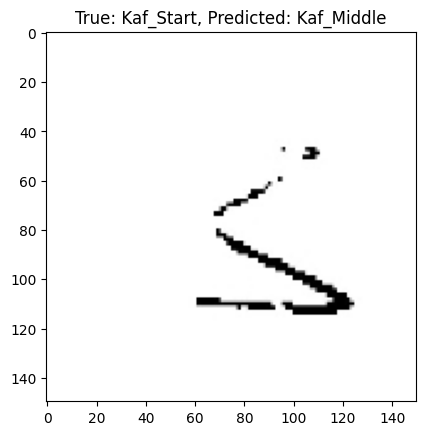

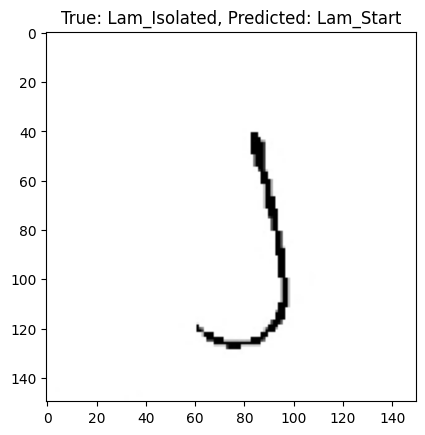

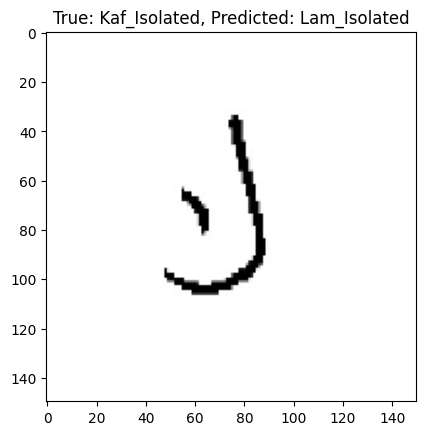

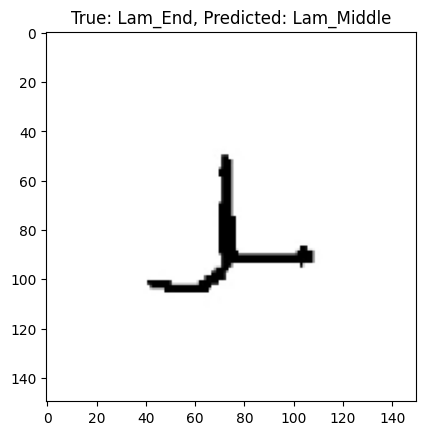

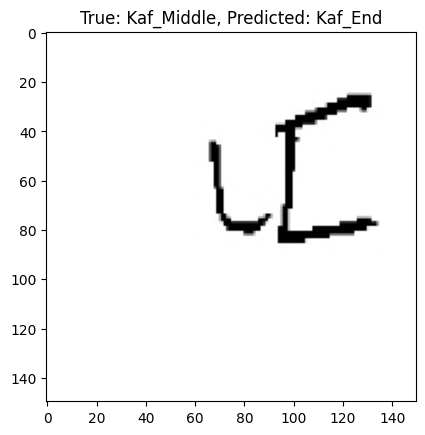

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### remove dropOut and decrease epochs 

In [30]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [31]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.2340 - loss: 1.9360 - val_accuracy: 0.7604 - val_loss: 0.6910
Epoch 2/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6896 - loss: 0.8661 - val_accuracy: 0.8474 - val_loss: 0.4557
Epoch 3/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.7909 - loss: 0.5950 - val_accuracy: 0.8434 - val_loss: 0.4341
Epoch 4/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.8420 - loss: 0.4562 - val_accuracy: 0.8661 - val_loss: 0.3909
Epoch 5/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8567 - loss: 0.4210 - val_accuracy: 0.8822 - val_loss: 0.3265
Epoch 6/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8812 - loss: 0.3726 - val_accuracy: 0.8889 - val_loss: 0.3308
Epoch 7/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9005 - loss: 0.2999 - val_accuracy: 0.9210 - val_loss: 0.2441
Epoch 8/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9130 - loss: 0.2655 - val_accuracy: 0

In [33]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9604 - loss: 0.1259
Train Accuracy: 95.98%
Test Accuracy: 95.98%


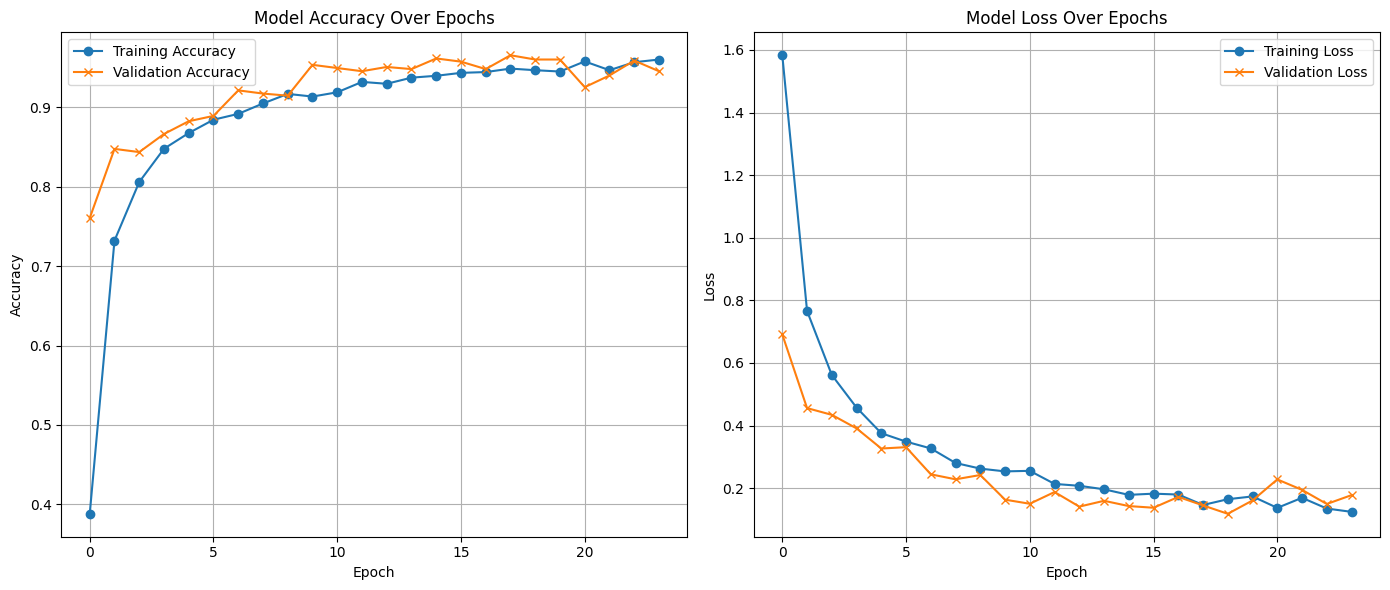

In [34]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


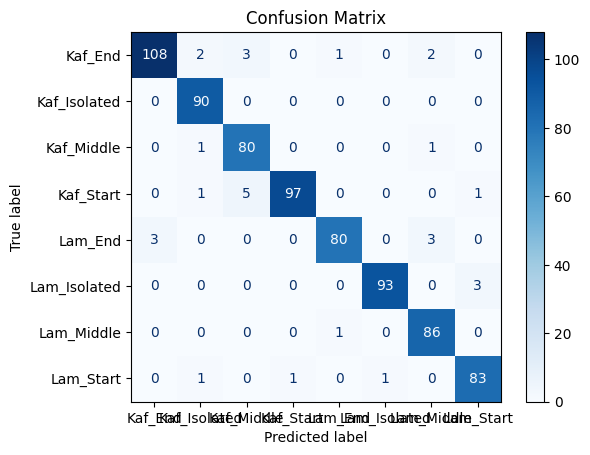

Number of incorrect predictions: 30


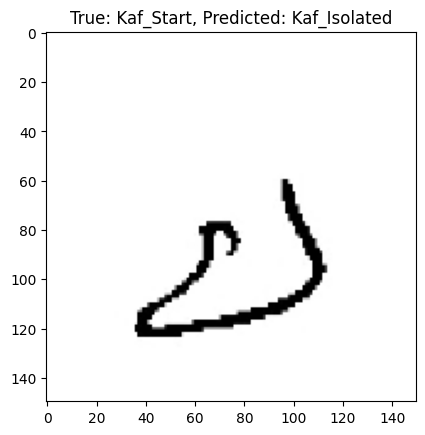

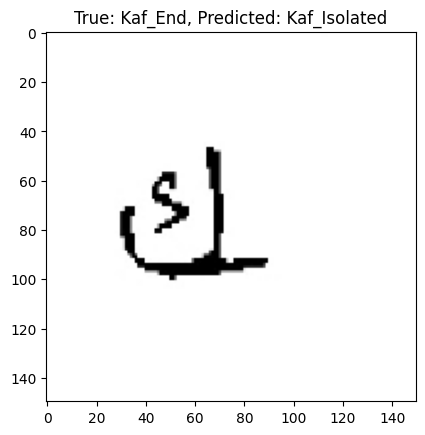

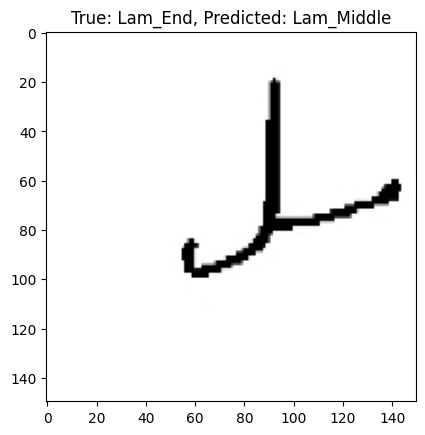

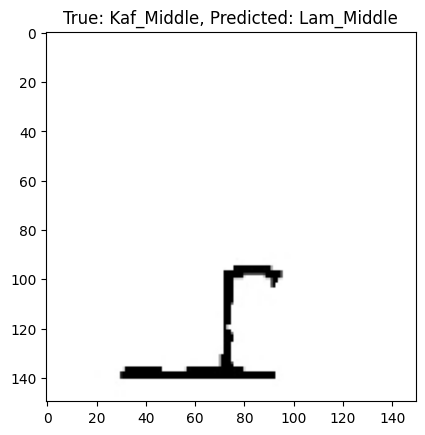

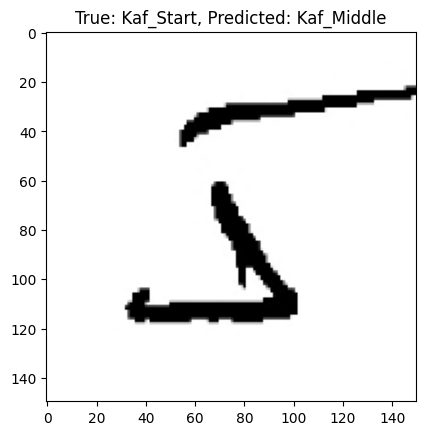

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [36]:
model.save("GrpJ.keras")